# EDA — Análise Exploratória dos Dados
## International Football Results (1872–2026)

**Objetivo:** Entender a estrutura dos dados, identificar padrões e preparar a base para engenharia de features.

**Dataset:** `data/raw/results.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 1. Carregamento dos Dados

In [2]:
df = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])
print(f'Shape: {df.shape}')
df.head()

Shape: (49287, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [3]:
# Tipos e valores nulos
df.info()
print('\nValores nulos por coluna:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[ns]
 1   home_team   49287 non-null  object        
 2   away_team   49287 non-null  object        
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49287 non-null  object        
 6   city        49287 non-null  object        
 7   country     49287 non-null  object        
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB

Valores nulos por coluna:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


## 2. Visão Geral dos Torneios

In [4]:
# Torneios mais frequentes
top_torneios = df['tournament'].value_counts().head(20)
print(top_torneios)

# Quantos jogos de Copa do Mundo?
copa = df[df['tournament'] == 'FIFA World Cup']
print(f'\nTotal de jogos de Copa do Mundo: {len(copa)}')
print(f'Copas disponíveis: {sorted(copa["date"].dt.year.unique())}')

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

Total de jogos de Copa do Mundo: 1036
Copa

## 3. Visualização 1 — Distribuição de Gols por Jogo

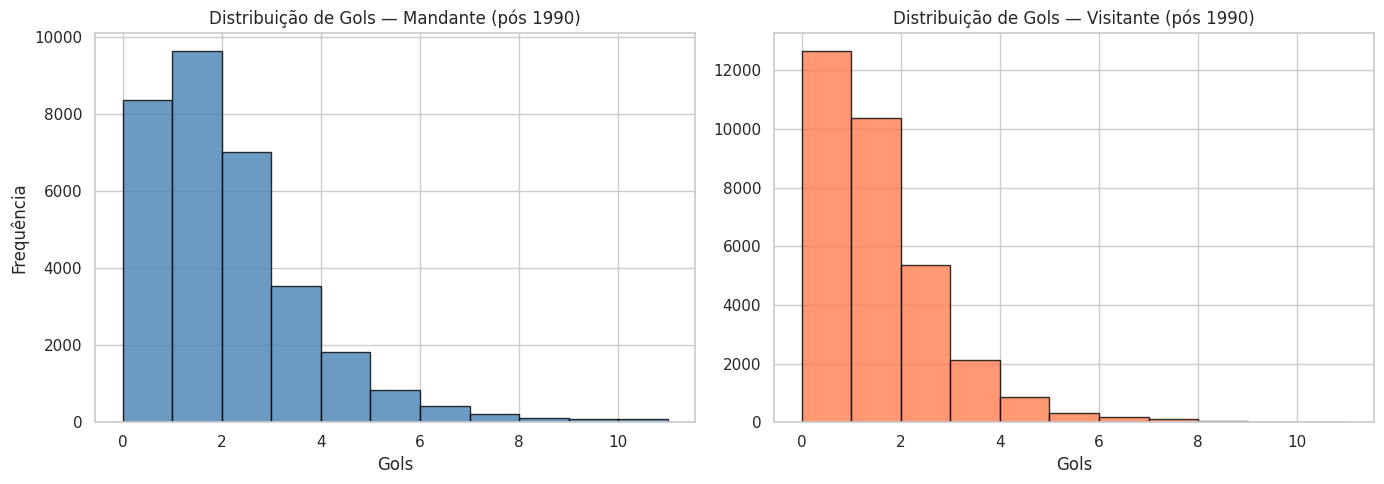

In [5]:
# Filtrar apenas período relevante (pós 1990)
df_moderno = df[df['date'].dt.year >= 1990].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_moderno['home_score'], bins=range(0, 12), edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title('Distribuição de Gols — Mandante (pós 1990)')
axes[0].set_xlabel('Gols')
axes[0].set_ylabel('Frequência')

axes[1].hist(df_moderno['away_score'], bins=range(0, 12), edgecolor='black', color='coral', alpha=0.8)
axes[1].set_title('Distribuição de Gols — Visitante (pós 1990)')
axes[1].set_xlabel('Gols')

plt.tight_layout()
plt.savefig('../article/figures/viz1_distribuicao_gols.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Visualização 2 — Média de Gols por Copa do Mundo

/tmp/ipykernel_34/2319895310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copa['ano'] = copa['date'].dt.year
/tmp/ipykernel_34/2319895310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  copa['total_gols'] = copa['home_score'] + copa['away_score']


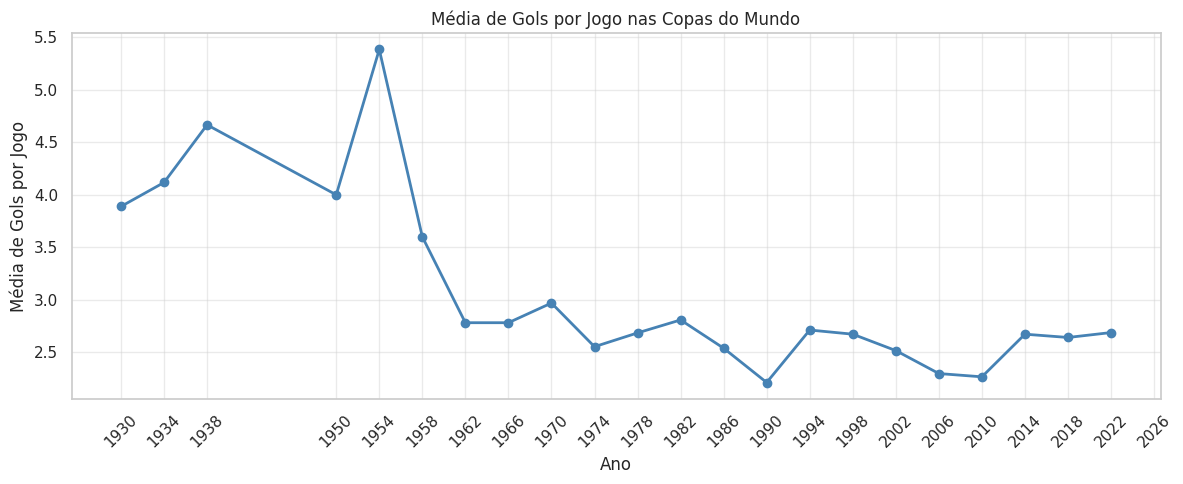

In [6]:
copa['ano'] = copa['date'].dt.year
copa['total_gols'] = copa['home_score'] + copa['away_score']
media_gols_copa = copa.groupby('ano')['total_gols'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(media_gols_copa['ano'], media_gols_copa['total_gols'], marker='o', linewidth=2, color='steelblue')
plt.title('Média de Gols por Jogo nas Copas do Mundo')
plt.xlabel('Ano')
plt.ylabel('Média de Gols por Jogo')
plt.xticks(media_gols_copa['ano'], rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../article/figures/viz2_media_gols_copa.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Visualização 3 — Amistosos vs. Jogos Competitivos

/tmp/ipykernel_34/2304894668.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_moderno, x='tipo', y='total_gols', palette='Set2')


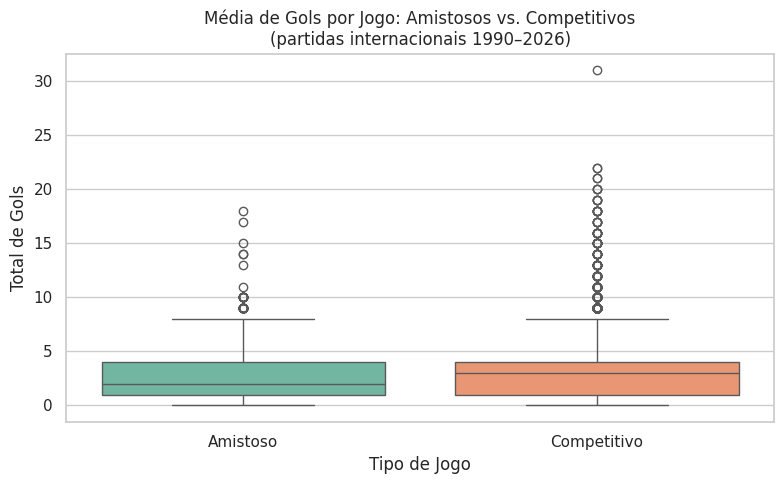

               count      mean       std  min  25%  50%  75%   max
tipo                                                              
Amistoso     10697.0  2.546602  1.768402  0.0  1.0  2.0  4.0  18.0
Competitivo  21404.0  2.864324  2.076111  0.0  1.0  3.0  4.0  31.0


In [7]:
df_moderno['tipo'] = df_moderno['tournament'].apply(
    lambda x: 'Amistoso' if x == 'Friendly' else 'Competitivo'
)
df_moderno['total_gols'] = df_moderno['home_score'] + df_moderno['away_score']

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_moderno, x='tipo', y='total_gols', palette='Set2')
plt.title('Média de Gols por Jogo: Amistosos vs. Competitivos\n(partidas internacionais 1990–2026)')
plt.xlabel('Tipo de Jogo')
plt.ylabel('Total de Gols')
plt.tight_layout()
plt.savefig('../article/figures/viz3_amistoso_vs_competitivo.png', dpi=150, bbox_inches='tight')
plt.show()

print(df_moderno.groupby('tipo')['total_gols'].describe())

## 6. Visualização 4 — Top 10 Seleções por Média de Gols (Ciclo 2022)

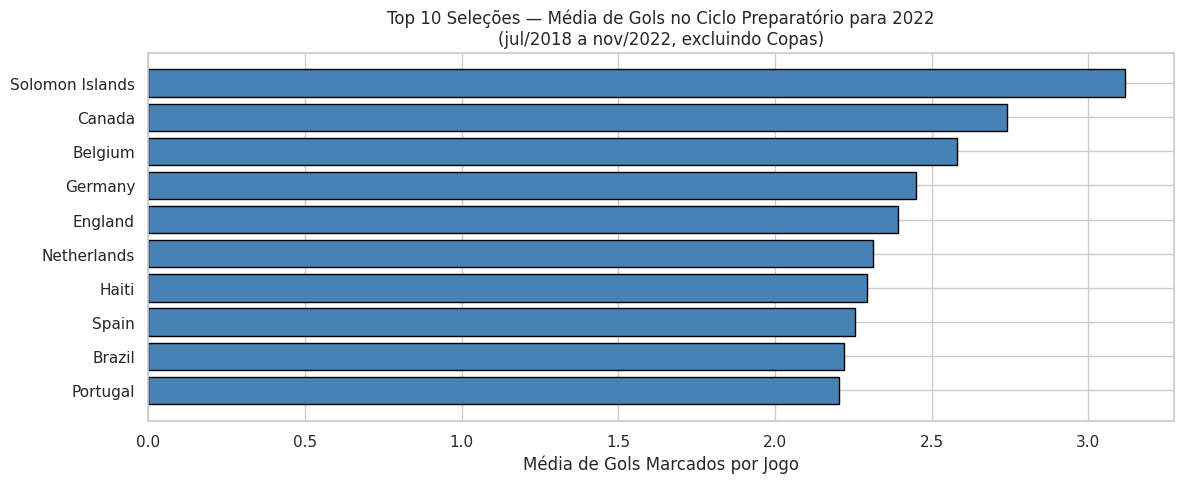

In [8]:
# Ciclo 2022: após Copa 2018 (julho/2018) até início Copa 2022 (novembro/2022)
ciclo_2022 = df[
    (df['date'] >= '2018-07-16') &
    (df['date'] < '2022-11-20') &
    (df['tournament'] != 'FIFA World Cup')
].copy()

# Calcular média de gols marcados por seleção (como mandante e visitante)
home = ciclo_2022[['home_team', 'home_score']].rename(columns={'home_team': 'selecao', 'home_score': 'gols'})
away = ciclo_2022[['away_team', 'away_score']].rename(columns={'away_team': 'selecao', 'away_score': 'gols'})
todos = pd.concat([home, away])

media_por_selecao = todos.groupby('selecao').agg(
    media_gols=('gols', 'mean'),
    total_jogos=('gols', 'count')
).reset_index()

# Filtrar seleções com pelo menos 15 jogos para ter dados confiáveis
media_por_selecao = media_por_selecao[media_por_selecao['total_jogos'] >= 15]
top10 = media_por_selecao.nlargest(10, 'media_gols')

plt.figure(figsize=(12, 5))
bars = plt.barh(top10['selecao'], top10['media_gols'], color='steelblue', edgecolor='black')
plt.xlabel('Média de Gols Marcados por Jogo')
plt.title('Top 10 Seleções — Média de Gols no Ciclo Preparatório para 2022\n(jul/2018 a nov/2022, excluindo Copas)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../article/figures/viz4_top10_ciclo2022.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Visualização 5 — Correlação: Forma Recente vs. Desempenho na Copa

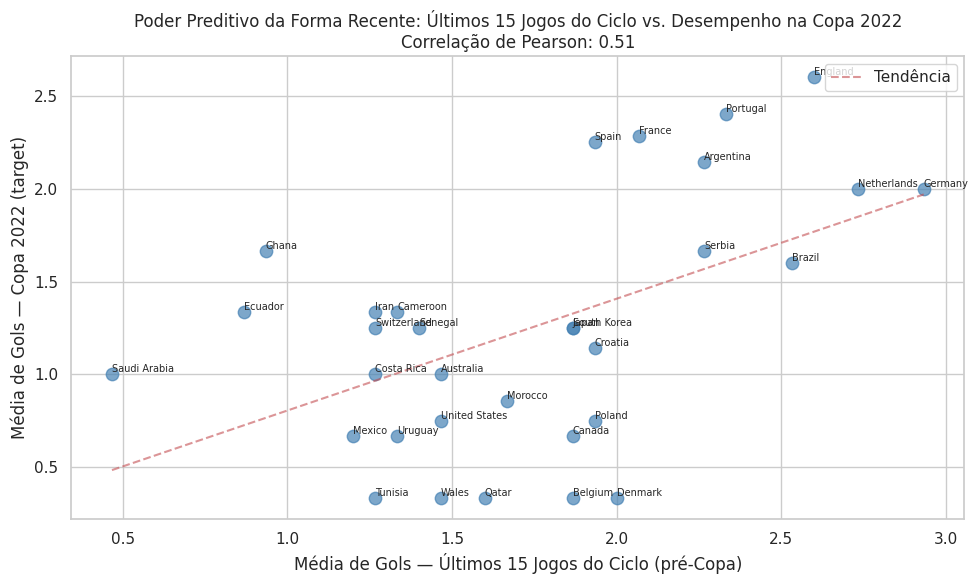

Correlação de Pearson: 0.5127


In [9]:
# Seleções que participaram da Copa 2022
copa_2022 = df[
    (df['tournament'] == 'FIFA World Cup') &
    (df['date'].dt.year == 2022)
].copy()

selecoes_2022 = pd.unique(
    copa_2022[['home_team', 'away_team']].values.ravel()
)

# Para cada seleção: média dos últimos 15 jogos no ciclo e média na Copa
resultados = []
for selecao in selecoes_2022:
    jogos_ciclo = ciclo_2022[
        (ciclo_2022['home_team'] == selecao) | (ciclo_2022['away_team'] == selecao)
    ].sort_values('date').tail(15)
    
    gols_ciclo = []
    for _, row in jogos_ciclo.iterrows():
        if row['home_team'] == selecao:
            gols_ciclo.append(row['home_score'])
        else:
            gols_ciclo.append(row['away_score'])
    
    jogos_copa = copa_2022[
        (copa_2022['home_team'] == selecao) | (copa_2022['away_team'] == selecao)
    ]
    gols_copa = []
    for _, row in jogos_copa.iterrows():
        if row['home_team'] == selecao:
            gols_copa.append(row['home_score'])
        else:
            gols_copa.append(row['away_score'])
    
    if len(gols_ciclo) > 0 and len(gols_copa) > 0:
        resultados.append({
            'selecao': selecao,
            'media_ult15': np.mean(gols_ciclo),
            'media_copa': np.mean(gols_copa)
        })

df_corr = pd.DataFrame(resultados)

plt.figure(figsize=(10, 6))
plt.scatter(df_corr['media_ult15'], df_corr['media_copa'], color='steelblue', alpha=0.7, s=80)
for _, row in df_corr.iterrows():
    plt.annotate(row['selecao'], (row['media_ult15'], row['media_copa']),
                 fontsize=7, ha='left', va='bottom')

# Linha de tendência
z = np.polyfit(df_corr['media_ult15'], df_corr['media_copa'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_corr['media_ult15'].min(), df_corr['media_ult15'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.6, label='Tendência')

corr = df_corr['media_ult15'].corr(df_corr['media_copa'])
plt.title(f'Poder Preditivo da Forma Recente: Últimos 15 Jogos do Ciclo vs. Desempenho na Copa 2022\nCorrelação de Pearson: {corr:.2f}')
plt.xlabel('Média de Gols — Últimos 15 Jogos do Ciclo (pré-Copa)')
plt.ylabel('Média de Gols — Copa 2022 (target)')
plt.legend()
plt.tight_layout()
plt.savefig('../article/figures/viz5_correlacao_forma_copa.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlação de Pearson: {corr:.4f}')

## 8. Resumo da EDA

**Principais observações:**
- A ser preenchido após executar as células acima

**Próximo passo:** `02_features.ipynb` — construção do dataset de features e targets para modelagem.